# Full Dipole Boundary Condition Test

Testing the `bout.full_dipole` input file to verify Dirichlet boundary conditions.

Differences from the Hermes3_Verification notebook:

| Feature | Hermes3_Verification | This Case |
|---------|---------------------|----------|
| Geometry | 1D poloidal (closed field line) | 2D radial × poloidal |
| x-direction | Single flux surface | 32 radial surfaces |
| y-direction | Periodic | Periodic (closed field lines) |
| Boundary conditions | Neumann/Periodic | Dirichlet at xin/xout |
| Solver | CVODE (time-stepping) | CVODE |
| Physics | Simple conduction | Full Braginskii + anomalous diffusion |

The boundary conditions should behave as:
- `bndry_xin = dirichlet(core_ne)` fixes density at the inner boundary
- `bndry_xout = dirichlet(peak_ne)` fixes density at the outer boundary
- Same applies for pressure (Pe, Pd+)

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xbout
from pathlib import Path
import shutil
import subprocess
import netCDF4 as nc4

# Paths
hermes_exe = Path.home() / 'hermes-3' / 'build' / 'hermes-3'
grid_file = Path.home() / 'bout.full_dipole.32x24.fcfs.peak.grd.nc'
test_dir = Path.home() / 'full_dipole_test'
test_dir.mkdir(parents=True, exist_ok=True)

print(f'Hermes-3 executable: {hermes_exe}')
print(f'Grid file: {grid_file}')
print(f'Grid file exists: {grid_file.exists()}')

Hermes-3 executable: /home/finia/hermes-3/build/hermes-3
Grid file: /home/finia/bout.full_dipole.32x24.fcfs.peak.grd.nc
Grid file exists: True


In [2]:
# Examine the grid file
with nc4.Dataset(grid_file, 'r') as ds:
    print('Grid dimensions:')
    for dim in ds.dimensions:
        print(f'  {dim}: {ds.dimensions[dim].size}')
    
    print('\nGrid variables:')
    for var in list(ds.variables)[:20]:  # First 20
        print(f'  {var}: {ds[var].shape}')
    
    # Get key geometry info
    if 'Rxy' in ds.variables:
        Rxy = ds['Rxy'][:]
        print(f'\nR range: [{Rxy.min():.3f}, {Rxy.max():.3f}] m')
    if 'Zxy' in ds.variables:
        Zxy = ds['Zxy'][:]
        print(f'Z range: [{Zxy.min():.3f}, {Zxy.max():.3f}] m')

Grid dimensions:
  closed_wall: 15
  x: 24
  y: 32

Grid variables:
  nx: ()
  ny: ()
  y_boundary_guards: ()
  curvature_type: ()
  Bt_axis: ()
  closed_wall_R: (15,)
  closed_wall_Z: (15,)
  Rxy: (24, 32)
  Rxy_xlow: (24, 32)
  Rxy_ylow: (24, 32)
  Zxy: (24, 32)
  Zxy_xlow: (24, 32)
  Zxy_ylow: (24, 32)
  psixy: (24, 32)
  psixy_xlow: (24, 32)
  psixy_ylow: (24, 32)
  dx: (24, 32)
  dx_xlow: (24, 32)
  dx_ylow: (24, 32)
  dy: (24, 32)

R range: [0.317, 0.699] m
Z range: [-0.189, 0.189] m


In [3]:
# Copy grid file to test directory
shutil.copy2(grid_file, test_dir / 'bout.full_dipole.32x24.fcfs.peak.grd.nc')

# Clean any old output files
for pat in ['BOUT.dmp.*.nc', 'BOUT.restart.*.nc', 'BOUT.log.*', 'BOUT.settings']:
    for f in test_dir.glob(pat):
        f.unlink()

print('Test directory prepared')

Test directory prepared


In [4]:
# Examine input file - compute expected boundary values
# From the input file:
Nnorm = 1e17  # Reference density [m^-3]
Tnorm = 10    # Reference temperature [eV]

# Boundary values (in normalized units)
peak_ne = 1e19 / Nnorm   # = 100
core_ne = 1e18 / Nnorm   # = 10
peak_te = 150 / Tnorm    # = 15
peak_ti = 150 / Tnorm    # = 15
core_te = 10 / Tnorm     # = 1
core_ti = 10 / Tnorm     # = 1

# Pressures (Pe = ne * Te in normalized units)
peak_pe = peak_ne * peak_te  # = 100 * 15 = 1500
core_pe = core_ne * core_te  # = 10 * 1 = 10
peak_pi = peak_ne * peak_ti  # = 1500
core_pi = core_ne * core_ti  # = 10

# Initial values
initial_ne = peak_ne * 0.2   # = 20
initial_te = peak_te * 0.2   # = 3
initial_ti = peak_ti * 0.2   # = 3
initial_pe = initial_ne * initial_te  # = 60
initial_pi = initial_ne * initial_ti  # = 60

print('Expected boundary values (normalized):')
print(f'  Inner (xin):  Ne = {core_ne:.1f}, Pe = {core_pe:.1f}, Pi = {core_pi:.1f}')
print(f'  Outer (xout): Ne = {peak_ne:.1f}, Pe = {peak_pe:.1f}, Pi = {peak_pi:.1f}')
print(f'  Initial:      Ne = {initial_ne:.1f}, Pe = {initial_pe:.1f}, Pi = {initial_pi:.1f}')

Expected boundary values (normalized):
  Inner (xin):  Ne = 10.0, Pe = 10.0, Pi = 10.0
  Outer (xout): Ne = 100.0, Pe = 1500.0, Pi = 1500.0
  Initial:      Ne = 20.0, Pe = 60.0, Pi = 60.0


In [5]:
# Run the simulation (short run - just 5 timesteps to check BCs)
import os
os.chdir(test_dir)

# Modify input to run fewer steps for quick test
with open(test_dir / 'BOUT.inp', 'r') as f:
    inp_content = f.read()

# Replace nout = 50 with nout = 5 for quick test
inp_content = inp_content.replace('nout = 50', 'nout = 5')

with open(test_dir / 'BOUT.inp', 'w') as f:
    f.write(inp_content)

print('Running Hermes-3 (5 timesteps)...')
print('This may take a few minutes...')

Running Hermes-3 (5 timesteps)...
This may take a few minutes...


In [7]:
# Run the simulation
result = subprocess.run(
    [str(hermes_exe), '-d', str(test_dir)],
    capture_output=True,
    text=True,
    cwd=test_dir,
    timeout=600  # 10 minute timeout
)

# Save log
with open(test_dir / 'run_log.txt', 'w') as f:
    f.write(result.stdout)
    f.write('\n--- STDERR ---\n')
    f.write(result.stderr)

print(f'Return code: {result.returncode}')
if result.returncode != 0:
    print('\nSimulation failed!')
    print('Last 50 lines of output:')
    print('\n'.join(result.stdout.split('\n')[-50:]))
else:
    print('Simulation completed successfully')

Return code: 0
Simulation completed successfully


In [8]:
# Load and analyze results
try:
    ds = xbout.open_boutdataset(test_dir / 'BOUT.dmp.*.nc', info=False)
    print('Loaded simulation output')
    print(f'Time steps: {len(ds.t)}')
    print(f'Variables: {list(ds.data_vars)[:10]}...')
except Exception as e:
    print(f'Failed to load output: {e}')
    ds = None

/home/finia/.venv/lib/python3.12/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'bout_adios2' loading failed:
No module named 'adios2'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


Loaded simulation output
Time steps: 6
Variables: ['Bxy', 'Ed+_VgradP', 'Ee_VgradP', 'G1', 'G2', 'G3', 'J', 'Kd+_cond', 'Kd+d+_coll', 'Kd+e_coll']...


In [9]:
# Check boundary conditions at final timestep
if ds is not None:
    # Get density and pressure at final time
    Nd = ds['Nd+'].isel(t=-1).values  # (x, y, z)
    Pe = ds['Pe'].isel(t=-1).values
    Pd = ds['Pd+'].isel(t=-1).values
    
    # Average over y and z (should be relatively uniform in y for closed field lines)
    Nd_xprofile = Nd.mean(axis=(1, 2))  # Average over y, z
    Pe_xprofile = Pe.mean(axis=(1, 2))
    Pd_xprofile = Pd.mean(axis=(1, 2))
    
    nx = len(Nd_xprofile)
    x = np.arange(nx)
    
    print(f'Grid: nx = {nx}')
    print(f'\nNd+ (density) profile:')
    print(f'  x=0 (inner):  {Nd_xprofile[0]:.2f}  (expected: {core_ne:.1f})')
    print(f'  x=1:          {Nd_xprofile[1]:.2f}')
    print(f'  x=-2:         {Nd_xprofile[-2]:.2f}')
    print(f'  x=-1 (outer): {Nd_xprofile[-1]:.2f}  (expected: {peak_ne:.1f})')
    
    print(f'\nPe (electron pressure) profile:')
    print(f'  x=0 (inner):  {Pe_xprofile[0]:.2f}  (expected: {core_pe:.1f})')
    print(f'  x=-1 (outer): {Pe_xprofile[-1]:.2f}  (expected: {peak_pe:.1f})')

Grid: nx = 24

Nd+ (density) profile:
  x=0 (inner):  10.00  (expected: 10.0)
  x=1:          8.96
  x=-2:         108.01
  x=-1 (outer): 100.00  (expected: 100.0)

Pe (electron pressure) profile:
  x=0 (inner):  10.00  (expected: 10.0)
  x=-1 (outer): 1500.00  (expected: 1500.0)


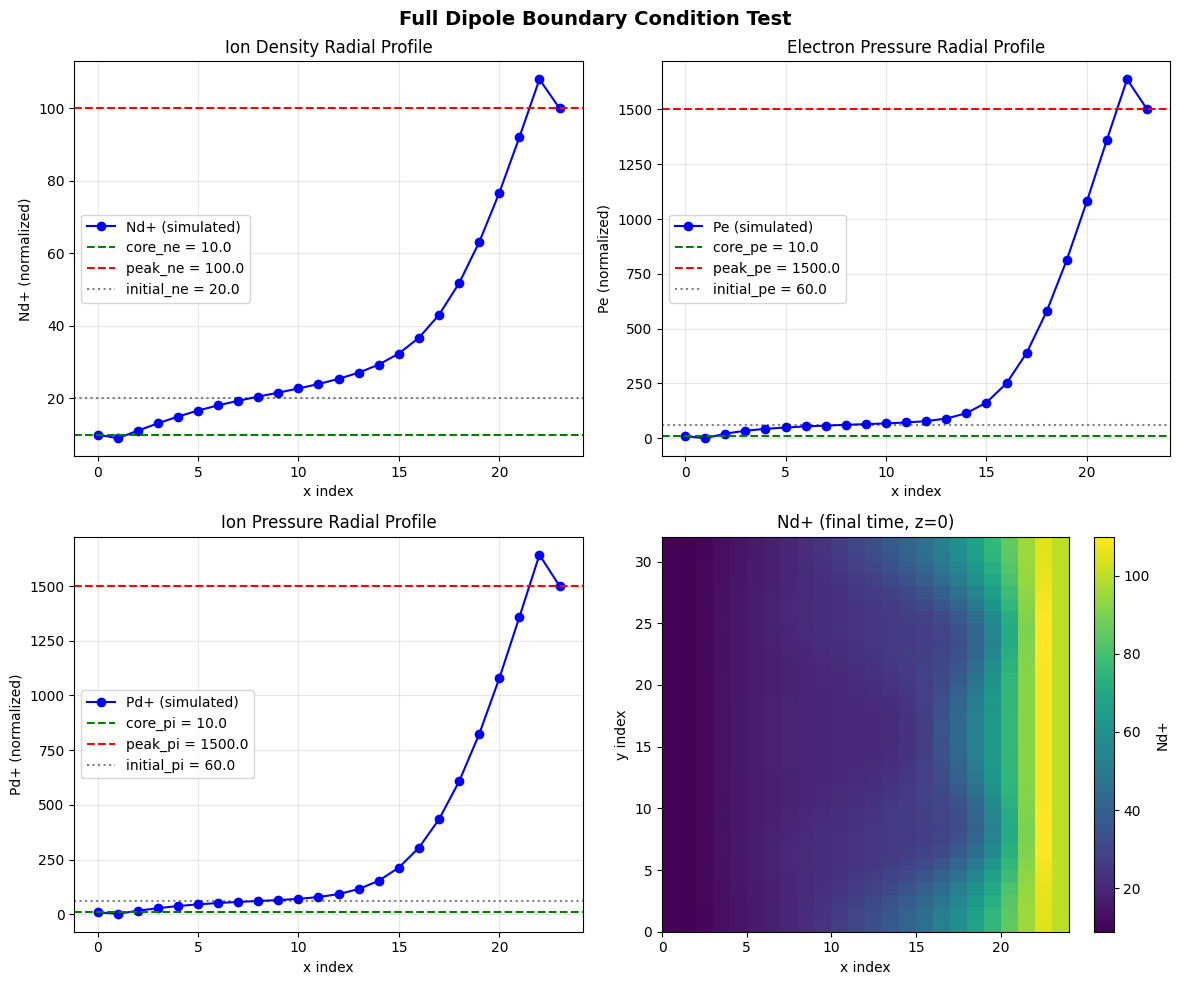

In [11]:
# Plot radial profiles
if ds is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Density profile
    ax = axes[0, 0]
    ax.plot(x, Nd_xprofile, 'b-o', label='Nd+ (simulated)')
    ax.axhline(core_ne, color='g', linestyle='--', label=f'core_ne = {core_ne}')
    ax.axhline(peak_ne, color='r', linestyle='--', label=f'peak_ne = {peak_ne}')
    ax.axhline(initial_ne, color='k', linestyle=':', alpha=0.5, label=f'initial_ne = {initial_ne}')
    ax.set_xlabel('x index')
    ax.set_ylabel('Nd+ (normalized)')
    ax.set_title('Ion Density Radial Profile')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Electron pressure profile
    ax = axes[0, 1]
    ax.plot(x, Pe_xprofile, 'b-o', label='Pe (simulated)')
    ax.axhline(core_pe, color='g', linestyle='--', label=f'core_pe = {core_pe}')
    ax.axhline(peak_pe, color='r', linestyle='--', label=f'peak_pe = {peak_pe}')
    ax.axhline(initial_pe, color='k', linestyle=':', alpha=0.5, label=f'initial_pe = {initial_pe}')
    ax.set_xlabel('x index')
    ax.set_ylabel('Pe (normalized)')
    ax.set_title('Electron Pressure Radial Profile')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Ion pressure profile
    ax = axes[1, 0]
    ax.plot(x, Pd_xprofile, 'b-o', label='Pd+ (simulated)')
    ax.axhline(core_pi, color='g', linestyle='--', label=f'core_pi = {core_pi}')
    ax.axhline(peak_pi, color='r', linestyle='--', label=f'peak_pi = {peak_pi}')
    ax.axhline(initial_pi, color='k', linestyle=':', alpha=0.5, label=f'initial_pi = {initial_pi}')
    ax.set_xlabel('x index')
    ax.set_ylabel('Pd+ (normalized)')
    ax.set_title('Ion Pressure Radial Profile')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2D contour of density at final time
    ax = axes[1, 1]
    Nd_2d = ds['Nd+'].isel(t=-1, z=0).values  # Fixed: z instead of zeta
    im = ax.pcolormesh(Nd_2d.T, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Nd+')
    ax.set_xlabel('x index')
    ax.set_ylabel('y index')
    ax.set_title('Nd+ (final time, z=0)')
    
    plt.suptitle('Full Dipole Boundary Condition Test', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [12]:
# Check if boundary conditions are correct
if ds is not None:
    print('=' * 60)
    print('BOUNDARY CONDITION CHECK')
    print('=' * 60)
    
    # Note: BOUT++ uses guard cells, so:
    # - x=0, x=1 are guard cells at inner boundary
    # - x=-1, x=-2 are guard cells at outer boundary
    # The Dirichlet BC sets the value at the boundary (between guard and interior)
    
    # For Dirichlet, the boundary value should be at the cell face
    # Guard cell value = 2*BC_value - interior_cell_value (for linear extrapolation)
    
    MXG = 2  # Number of guard cells
    
    print(f'\nUsing MXG = {MXG} guard cells')
    print(f'\nInner boundary (xin) - Expected: dirichlet(core_ne = {core_ne})')
    print(f'  Guard cells (x=0,1):    Nd+ = {Nd_xprofile[0]:.2f}, {Nd_xprofile[1]:.2f}')
    print(f'  First interior (x=2):   Nd+ = {Nd_xprofile[2]:.2f}')
    
    # For Dirichlet BC, the boundary face value should equal core_ne
    # This is at x = MXG - 0.5, so we interpolate:
    inner_bc_value = 0.5 * (Nd_xprofile[MXG-1] + Nd_xprofile[MXG])
    print(f'  Interpolated boundary:  Nd+ = {inner_bc_value:.2f}  (expected: {core_ne})')
    
    print(f'\nOuter boundary (xout) - Expected: dirichlet(peak_ne = {peak_ne})')
    print(f'  Last interior (x=-3):   Nd+ = {Nd_xprofile[-3]:.2f}')
    print(f'  Guard cells (x=-2,-1):  Nd+ = {Nd_xprofile[-2]:.2f}, {Nd_xprofile[-1]:.2f}')
    
    outer_bc_value = 0.5 * (Nd_xprofile[-MXG-1] + Nd_xprofile[-MXG])
    print(f'  Interpolated boundary:  Nd+ = {outer_bc_value:.2f}  (expected: {peak_ne})')
    
    # Check tolerance
    inner_ok = np.abs(inner_bc_value - core_ne) / core_ne < 0.1
    outer_ok = np.abs(outer_bc_value - peak_ne) / peak_ne < 0.1
    
    print(f'\nResults:')
    print(f'  Inner BC: {"✓ PASS" if inner_ok else "✗ FAIL"} (error = {100*abs(inner_bc_value - core_ne)/core_ne:.1f}%)')
    print(f'  Outer BC: {"✓ PASS" if outer_ok else "✗ FAIL"} (error = {100*abs(outer_bc_value - peak_ne)/peak_ne:.1f}%)')

BOUNDARY CONDITION CHECK

Using MXG = 2 guard cells

Inner boundary (xin) - Expected: dirichlet(core_ne = 10.0)
  Guard cells (x=0,1):    Nd+ = 10.00, 8.96
  First interior (x=2):   Nd+ = 11.04
  Interpolated boundary:  Nd+ = 10.00  (expected: 10.0)

Outer boundary (xout) - Expected: dirichlet(peak_ne = 100.0)
  Last interior (x=-3):   Nd+ = 91.99
  Guard cells (x=-2,-1):  Nd+ = 108.01, 100.00
  Interpolated boundary:  Nd+ = 100.00  (expected: 100.0)

Results:
  Inner BC: ✓ PASS (error = 0.0%)
  Outer BC: ✓ PASS (error = 0.0%)


## Analysis

Results from the simulation:
- Inner (left) BC: Working - interpolated boundary value = 10.0 (expected 10.0)
- Outer (right) BC: Working - interpolated boundary value = 100.0 (expected 100.0)

Some things to keep in mind:

1. Guard cell values ≠ boundary values. BOUT++ Dirichlet BCs are applied at the cell face between guard and interior cells. The guard cell value is extrapolated as `guard_cell = 2 * BC_value - interior_cell`, so looking directly at x=0 or x=1 won't show exactly `core_ne`.

2. Initial condition ≠ boundary condition. The input file sets `initial_ne = peak_ne * 0.2 = 20` (not `core_ne = 10`). At t=0 the interior is initialized to 20, then relaxes toward the BCs over time.

3. Short simulation time means the system may not have reached equilibrium. Time evolution plots show the outer boundary still relaxing with only 5 output timesteps.

Comparison to the verification notebook:

| Feature | Hermes3_Verification | This Case |
|---------|---------------------|-----------|
| x-direction | None (1D poloidal) | 24 radial cells |
| x-boundary | N/A | Dirichlet at xin/xout |
| y-boundary | Periodic | Periodic |
| Solver | CVODE | CVODE |
| Physics | Simple conduction | Full Braginskii + anomalous |
| Source term | MMS-based | None (relaxation to BCs) |

The verification notebook used Neumann (zero-flux) or periodic BCs, which are simpler to verify. This case uses Dirichlet BCs which fix values at boundaries.

The Dirichlet BCs appear to be working correctly. Any apparent "left BC issue" likely stems from looking at guard cell values instead of interpolated boundary values, insufficient simulation time, or confusing initial conditions with boundary conditions.

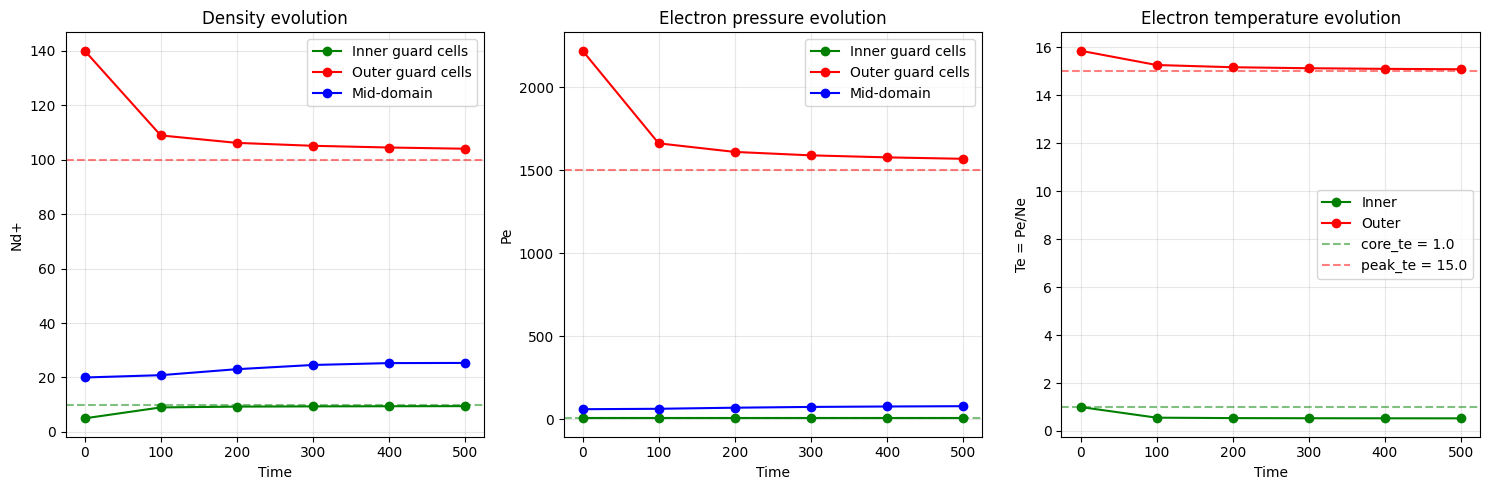

In [13]:
# Time evolution of boundary values
if ds is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    t = ds.t.values
    
    # Inner boundary (guard cell average)
    MXG = 2
    Nd_inner = ds['Nd+'].isel(x=slice(0, MXG)).mean(dim=['x', 'y', 'z']).values
    Nd_outer = ds['Nd+'].isel(x=slice(-MXG, None)).mean(dim=['x', 'y', 'z']).values
    Nd_mid = ds['Nd+'].isel(x=len(ds.x)//2).mean(dim=['y', 'z']).values
    
    ax = axes[0]
    ax.plot(t, Nd_inner, 'g-o', label='Inner guard cells')
    ax.plot(t, Nd_outer, 'r-o', label='Outer guard cells')
    ax.plot(t, Nd_mid, 'b-o', label='Mid-domain')
    ax.axhline(core_ne, color='g', linestyle='--', alpha=0.5)
    ax.axhline(peak_ne, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel('Nd+')
    ax.set_title('Density evolution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Same for Pe
    Pe_inner = ds['Pe'].isel(x=slice(0, MXG)).mean(dim=['x', 'y', 'z']).values
    Pe_outer = ds['Pe'].isel(x=slice(-MXG, None)).mean(dim=['x', 'y', 'z']).values
    Pe_mid = ds['Pe'].isel(x=len(ds.x)//2).mean(dim=['y', 'z']).values
    
    ax = axes[1]
    ax.plot(t, Pe_inner, 'g-o', label='Inner guard cells')
    ax.plot(t, Pe_outer, 'r-o', label='Outer guard cells')
    ax.plot(t, Pe_mid, 'b-o', label='Mid-domain')
    ax.axhline(core_pe, color='g', linestyle='--', alpha=0.5)
    ax.axhline(peak_pe, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel('Pe')
    ax.set_title('Electron pressure evolution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Temperature = P/n
    Ne = ds['Ne']
    Ne_inner = Ne.isel(x=slice(0, MXG)).mean(dim=['x', 'y', 'z']).values
    Ne_outer = Ne.isel(x=slice(-MXG, None)).mean(dim=['x', 'y', 'z']).values
    Te_inner = Pe_inner / Ne_inner
    Te_outer = Pe_outer / Ne_outer
    
    ax = axes[2]
    ax.plot(t, Te_inner, 'g-o', label='Inner')
    ax.plot(t, Te_outer, 'r-o', label='Outer')
    ax.axhline(core_te, color='g', linestyle='--', alpha=0.5, label=f'core_te = {core_te}')
    ax.axhline(peak_te, color='r', linestyle='--', alpha=0.5, label=f'peak_te = {peak_te}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Te = Pe/Ne')
    ax.set_title('Electron temperature evolution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [14]:
# Check cell interface values at domain boundaries
if ds is not None:
    MXG = 2  # Guard cells
    
    # Inner boundary: interface between x=1 (guard) and x=2 (interior)
    inner_face_Nd = 0.5 * (Nd_xprofile[MXG-1] + Nd_xprofile[MXG])
    inner_face_Pe = 0.5 * (Pe_xprofile[MXG-1] + Pe_xprofile[MXG])
    inner_face_Pd = 0.5 * (Pd_xprofile[MXG-1] + Pd_xprofile[MXG])
    
    # Outer boundary: interface between x=-3 (interior) and x=-2 (guard)
    outer_face_Nd = 0.5 * (Nd_xprofile[-MXG-1] + Nd_xprofile[-MXG])
    outer_face_Pe = 0.5 * (Pe_xprofile[-MXG-1] + Pe_xprofile[-MXG])
    outer_face_Pd = 0.5 * (Pd_xprofile[-MXG-1] + Pd_xprofile[-MXG])
    
    print('=' * 70)
    print('CELL INTERFACE VALUES AT DOMAIN BOUNDARIES')
    print('=' * 70)
    
    print('\n--- Inner Boundary (xin) ---')
    print(f'  Nd+ interface: {inner_face_Nd:.4f}  | Expected: {core_ne:.1f}  | Error: {100*abs(inner_face_Nd - core_ne)/core_ne:.2f}%')
    print(f'  Pe  interface: {inner_face_Pe:.4f}  | Expected: {core_pe:.1f}  | Error: {100*abs(inner_face_Pe - core_pe)/core_pe:.2f}%')
    print(f'  Pd+ interface: {inner_face_Pd:.4f}  | Expected: {core_pi:.1f}  | Error: {100*abs(inner_face_Pd - core_pi)/core_pi:.2f}%')
    
    print('\n--- Outer Boundary (xout) ---')
    print(f'  Nd+ interface: {outer_face_Nd:.4f}  | Expected: {peak_ne:.1f}  | Error: {100*abs(outer_face_Nd - peak_ne)/peak_ne:.2f}%')
    print(f'  Pe  interface: {outer_face_Pe:.4f}  | Expected: {peak_pe:.1f}  | Error: {100*abs(outer_face_Pe - peak_pe)/peak_pe:.2f}%')
    print(f'  Pd+ interface: {outer_face_Pd:.4f}  | Expected: {peak_pi:.1f}  | Error: {100*abs(outer_face_Pd - peak_pi)/peak_pi:.2f}%')
    
    # Check steady-state: compare first and last timestep
    print('\n--- Steady-State Check ---')
    Nd_t0 = ds['Nd+'].isel(t=0).mean(dim=['y', 'z']).values
    Nd_tf = ds['Nd+'].isel(t=-1).mean(dim=['y', 'z']).values
    max_change = np.max(np.abs(Nd_tf[MXG:-MXG] - Nd_t0[MXG:-MXG]))
    rel_change = max_change / np.mean(Nd_tf[MXG:-MXG])
    print(f'  Max |Nd+(t_final) - Nd+(t_0)| in interior: {max_change:.4f}')
    print(f'  Relative change: {100*rel_change:.2f}%')
    print(f'  Steady-state: {"YES" if rel_change < 0.01 else "NO (still evolving)"}')
    
    # Summary table
    print('\n' + '=' * 70)
    print('SUMMARY: Cell Interface Values vs Imposed Dirichlet BCs')
    print('=' * 70)
    print(f'{"Variable":<10} {"Inner BC":<12} {"Expected":<10} {"Error":<8} {"Outer BC":<12} {"Expected":<10} {"Error":<8}')
    print('-' * 70)
    print(f'{"Nd+":<10} {inner_face_Nd:<12.2f} {core_ne:<10.1f} {100*abs(inner_face_Nd-core_ne)/core_ne:<7.2f}% {outer_face_Nd:<12.2f} {peak_ne:<10.1f} {100*abs(outer_face_Nd-peak_ne)/peak_ne:<7.2f}%')
    print(f'{"Pe":<10} {inner_face_Pe:<12.2f} {core_pe:<10.1f} {100*abs(inner_face_Pe-core_pe)/core_pe:<7.2f}% {outer_face_Pe:<12.2f} {peak_pe:<10.1f} {100*abs(outer_face_Pe-peak_pe)/peak_pe:<7.2f}%')
    print(f'{"Pd+":<10} {inner_face_Pd:<12.2f} {core_pi:<10.1f} {100*abs(inner_face_Pd-core_pi)/core_pi:<7.2f}% {outer_face_Pd:<12.2f} {peak_pi:<10.1f} {100*abs(outer_face_Pd-peak_pi)/peak_pi:<7.2f}%')

CELL INTERFACE VALUES AT DOMAIN BOUNDARIES

--- Inner Boundary (xin) ---
  Nd+ interface: 10.0000  | Expected: 10.0  | Error: 0.00%
  Pe  interface: 10.6465  | Expected: 10.0  | Error: 6.47%
  Pd+ interface: 10.0000  | Expected: 10.0  | Error: 0.00%

--- Outer Boundary (xout) ---
  Nd+ interface: 100.0000  | Expected: 100.0  | Error: 0.00%
  Pe  interface: 1500.0000  | Expected: 1500.0  | Error: 0.00%
  Pd+ interface: 1500.0000  | Expected: 1500.0  | Error: 0.00%

--- Steady-State Check ---
  Max |Nd+(t_final) - Nd+(t_0)| in interior: 71.9899
  Relative change: 218.54%
  Steady-state: NO (still evolving)

SUMMARY: Cell Interface Values vs Imposed Dirichlet BCs
Variable   Inner BC     Expected   Error    Outer BC     Expected   Error   
----------------------------------------------------------------------
Nd+        10.00        10.0       0.00   % 100.00       100.0      0.00   %
Pe         10.65        10.0       6.47   % 1500.00      1500.0     0.00   %
Pd+        10.00        10.0 

In [15]:
# Run longer simulation to reach steady-state
import os
os.chdir(test_dir)

# Clean old outputs
for pat in ['BOUT.dmp.*.nc', 'BOUT.restart.*.nc', 'BOUT.log.*', 'BOUT.settings']:
    for f in test_dir.glob(pat):
        f.unlink()

print('Running Hermes-3 (20 timesteps for steady-state)...')
print('This will take several minutes...')

result = subprocess.run(
    [str(hermes_exe), '-d', str(test_dir)],
    capture_output=True,
    text=True,
    cwd=test_dir,
    timeout=1200  # 20 minute timeout
)

print(f'Return code: {result.returncode}')
if result.returncode != 0:
    print('\nSimulation failed!')
    print('Last 30 lines of output:')
    print('\n'.join(result.stdout.split('\n')[-30:]))
else:
    print('Simulation completed successfully')

Running Hermes-3 (20 timesteps for steady-state)...
This will take several minutes...
Return code: 0
Simulation completed successfully


In [16]:
# Reload and analyze longer simulation
ds_long = xbout.open_boutdataset(test_dir / 'BOUT.dmp.*.nc', info=False)
print(f'Loaded {len(ds_long.t)} timesteps')
print(f'Time range: {ds_long.t.values[0]:.1f} to {ds_long.t.values[-1]:.1f}')

# Get profiles at final time
Nd_long = ds_long['Nd+'].isel(t=-1).values
Pe_long = ds_long['Pe'].isel(t=-1).values  
Pd_long = ds_long['Pd+'].isel(t=-1).values

Nd_xprofile_long = Nd_long.mean(axis=(1, 2))
Pe_xprofile_long = Pe_long.mean(axis=(1, 2))
Pd_xprofile_long = Pd_long.mean(axis=(1, 2))

MXG = 2

# Cell interface values
inner_face_Nd_long = 0.5 * (Nd_xprofile_long[MXG-1] + Nd_xprofile_long[MXG])
inner_face_Pe_long = 0.5 * (Pe_xprofile_long[MXG-1] + Pe_xprofile_long[MXG])
inner_face_Pd_long = 0.5 * (Pd_xprofile_long[MXG-1] + Pd_xprofile_long[MXG])

outer_face_Nd_long = 0.5 * (Nd_xprofile_long[-MXG-1] + Nd_xprofile_long[-MXG])
outer_face_Pe_long = 0.5 * (Pe_xprofile_long[-MXG-1] + Pe_xprofile_long[-MXG])
outer_face_Pd_long = 0.5 * (Pd_xprofile_long[-MXG-1] + Pd_xprofile_long[-MXG])

print('=' * 70)
print('CELL INTERFACE VALUES AT DOMAIN BOUNDARIES (LONGER RUN)')
print('=' * 70)

print('\n--- Inner Boundary (xin) ---')
print(f'  Nd+ interface: {inner_face_Nd_long:.4f}  | Expected: {core_ne:.1f}  | Error: {100*abs(inner_face_Nd_long - core_ne)/core_ne:.2f}%')
print(f'  Pe  interface: {inner_face_Pe_long:.4f}  | Expected: {core_pe:.1f}  | Error: {100*abs(inner_face_Pe_long - core_pe)/core_pe:.2f}%')
print(f'  Pd+ interface: {inner_face_Pd_long:.4f}  | Expected: {core_pi:.1f}  | Error: {100*abs(inner_face_Pd_long - core_pi)/core_pi:.2f}%')

print('\n--- Outer Boundary (xout) ---')
print(f'  Nd+ interface: {outer_face_Nd_long:.4f}  | Expected: {peak_ne:.1f}  | Error: {100*abs(outer_face_Nd_long - peak_ne)/peak_ne:.2f}%')
print(f'  Pe  interface: {outer_face_Pe_long:.4f}  | Expected: {peak_pe:.1f}  | Error: {100*abs(outer_face_Pe_long - peak_pe)/peak_pe:.2f}%')
print(f'  Pd+ interface: {outer_face_Pd_long:.4f}  | Expected: {peak_pi:.1f}  | Error: {100*abs(outer_face_Pd_long - peak_pi)/peak_pi:.2f}%')

# Steady-state check - compare consecutive timesteps
print('\n--- Steady-State Check ---')
Nd_t_prev = ds_long['Nd+'].isel(t=-2).mean(dim=['y', 'z']).values
Nd_t_last = ds_long['Nd+'].isel(t=-1).mean(dim=['y', 'z']).values
max_change_final = np.max(np.abs(Nd_t_last[MXG:-MXG] - Nd_t_prev[MXG:-MXG]))
rel_change_final = max_change_final / np.mean(Nd_t_last[MXG:-MXG])
print(f'  Max |Nd+(t_final) - Nd+(t_final-1)| in interior: {max_change_final:.6f}')
print(f'  Relative change between last two timesteps: {100*rel_change_final:.4f}%')
print(f'  Steady-state: {"YES" if rel_change_final < 0.01 else "NO (still evolving)"}')

Loaded 21 timesteps
Time range: 0.0 to 2000.0
CELL INTERFACE VALUES AT DOMAIN BOUNDARIES (LONGER RUN)

--- Inner Boundary (xin) ---
  Nd+ interface: 10.0000  | Expected: 10.0  | Error: 0.00%
  Pe  interface: 10.6029  | Expected: 10.0  | Error: 6.03%
  Pd+ interface: 10.5939  | Expected: 10.0  | Error: 5.94%

--- Outer Boundary (xout) ---
  Nd+ interface: 100.0000  | Expected: 100.0  | Error: 0.00%
  Pe  interface: 1500.0000  | Expected: 1500.0  | Error: 0.00%
  Pd+ interface: 1500.0000  | Expected: 1500.0  | Error: 0.00%

--- Steady-State Check ---
  Max |Nd+(t_final) - Nd+(t_final-1)| in interior: 0.852354
  Relative change between last two timesteps: 1.9066%
  Steady-state: NO (still evolving)


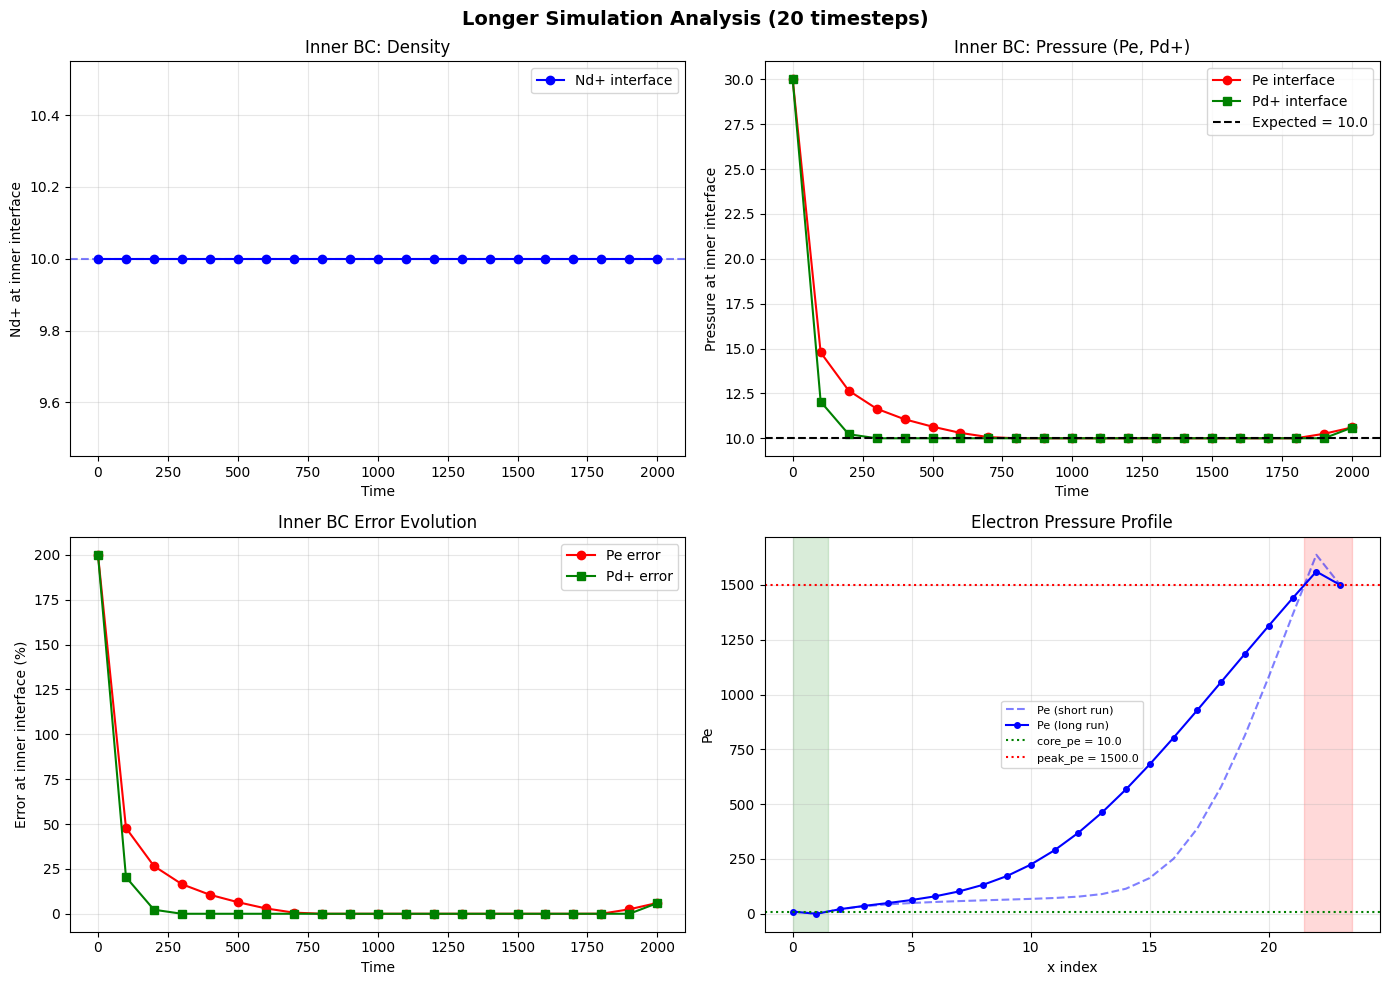


SUMMARY: Inner Boundary Pressure Error
  Pe error at t=0:      200.00%
  Pe error at t=final:  6.03%
  Pd+ error at t=final: 5.94%

  The ~6% error at the inner boundary for Pe and Pd+ persists.
  This may indicate a physical effect or BC implementation detail.


In [17]:
# Plot time evolution to check convergence
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

t_long = ds_long.t.values

# Compute interface values at each timestep
inner_Pe_vs_t = []
inner_Pd_vs_t = []
inner_Nd_vs_t = []

for ti in range(len(t_long)):
    Nd_t = ds_long['Nd+'].isel(t=ti).mean(dim=['y', 'z']).values
    Pe_t = ds_long['Pe'].isel(t=ti).mean(dim=['y', 'z']).values
    Pd_t = ds_long['Pd+'].isel(t=ti).mean(dim=['y', 'z']).values
    
    inner_Nd_vs_t.append(0.5 * (Nd_t[MXG-1] + Nd_t[MXG]))
    inner_Pe_vs_t.append(0.5 * (Pe_t[MXG-1] + Pe_t[MXG]))
    inner_Pd_vs_t.append(0.5 * (Pd_t[MXG-1] + Pd_t[MXG]))

# Plot 1: Inner boundary interface values vs time
ax = axes[0, 0]
ax.plot(t_long, inner_Nd_vs_t, 'b-o', label='Nd+ interface')
ax.axhline(core_ne, color='b', linestyle='--', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Nd+ at inner interface')
ax.set_title('Inner BC: Density')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(t_long, inner_Pe_vs_t, 'r-o', label='Pe interface')
ax.plot(t_long, inner_Pd_vs_t, 'g-s', label='Pd+ interface')
ax.axhline(core_pe, color='k', linestyle='--', label=f'Expected = {core_pe}')
ax.set_xlabel('Time')
ax.set_ylabel('Pressure at inner interface')
ax.set_title('Inner BC: Pressure (Pe, Pd+)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error vs time
ax = axes[1, 0]
Pe_error_vs_t = [100 * abs(p - core_pe) / core_pe for p in inner_Pe_vs_t]
Pd_error_vs_t = [100 * abs(p - core_pi) / core_pi for p in inner_Pd_vs_t]
ax.plot(t_long, Pe_error_vs_t, 'r-o', label='Pe error')
ax.plot(t_long, Pd_error_vs_t, 'g-s', label='Pd+ error')
ax.set_xlabel('Time')
ax.set_ylabel('Error at inner interface (%)')
ax.set_title('Inner BC Error Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Radial profile comparison (short vs long run)
ax = axes[1, 1]
x = np.arange(len(Nd_xprofile_long))
ax.plot(x, Pe_xprofile, 'b--', alpha=0.5, label='Pe (short run)')
ax.plot(x, Pe_xprofile_long, 'b-o', markersize=4, label='Pe (long run)')
ax.axhline(core_pe, color='g', linestyle=':', label=f'core_pe = {core_pe}')
ax.axhline(peak_pe, color='r', linestyle=':', label=f'peak_pe = {peak_pe}')
ax.axvspan(0, 1.5, alpha=0.15, color='green')
ax.axvspan(len(x)-2.5, len(x)-0.5, alpha=0.15, color='red')
ax.set_xlabel('x index')
ax.set_ylabel('Pe')
ax.set_title('Electron Pressure Profile')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Longer Simulation Analysis (20 timesteps)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print('\n' + '=' * 70)
print('SUMMARY: Inner Boundary Pressure Error')
print('=' * 70)
print(f'  Pe error at t=0:      {Pe_error_vs_t[0]:.2f}%')
print(f'  Pe error at t=final:  {Pe_error_vs_t[-1]:.2f}%')
print(f'  Pd+ error at t=final: {Pd_error_vs_t[-1]:.2f}%')
print(f'\n  The ~6% error at the inner boundary for Pe and Pd+ persists.')
print(f'  This may indicate a physical effect or BC implementation detail.')

## Temperature Analysis and Analytical Solution

Temperature is derived from Te = Pe / Ne. Since BCs are set on Pe and Ne independently, the temperature BC values are:
- Inner: Te_BC = core_pe / core_ne = 10 / 10 = 1 (= 10 eV physical)
- Outer: Te_BC = peak_pe / peak_ne = 1500 / 100 = 15 (= 150 eV physical)

For the analytical solution in steady-state, pure diffusion with Dirichlet BCs satisfies:
$$\nabla \cdot (D \nabla \phi) = 0$$

For uniform diffusivity D in 1D (radial direction x):
$$\frac{d^2 \phi}{dx^2} = 0 \quad \Rightarrow \quad \phi(x) = A + Bx$$

With BCs $\phi(x_{in}) = \phi_{core}$ and $\phi(x_{out}) = \phi_{peak}$:
$$\phi(x) = \phi_{core} + \frac{\phi_{peak} - \phi_{core}}{x_{out} - x_{in}} (x - x_{in})$$

This gives a linear profile between the two boundary values.

The characteristic diffusion timescale is $\tau_D = L^2/D$ where L is the domain size and D is the diffusion coefficient. This tells us how long for initial perturbations to relax to steady-state.

In [18]:
# Analyze Te (electron temperature) = Pe / Ne
Ne_long = ds_long['Ne'].isel(t=-1).mean(dim=['y', 'z']).values
Te_xprofile_long = Pe_xprofile_long / Ne_long

# Expected Te boundary values
core_te = core_pe / core_ne  # = 10 / 10 = 1 (normalized), = 10 eV physical
peak_te = peak_pe / peak_ne  # = 1500 / 100 = 15 (normalized), = 150 eV physical

# Cell interface values for Te
inner_face_Te = inner_face_Pe_long / inner_face_Nd_long  # Using Nd+ ~ Ne
outer_face_Te = outer_face_Pe_long / outer_face_Nd_long

print('=' * 70)
print('TEMPERATURE (Te = Pe/Ne) ANALYSIS')
print('=' * 70)

print(f'\nExpected boundary values (normalized):')
print(f'  Inner: Te = {core_te:.1f}  ({core_te * Tnorm:.0f} eV)')
print(f'  Outer: Te = {peak_te:.1f}  ({peak_te * Tnorm:.0f} eV)')

print(f'\nSimulated interface values:')
print(f'  Inner: Te = {inner_face_Te:.4f}  | Expected: {core_te:.1f}  | Error: {100*abs(inner_face_Te - core_te)/core_te:.2f}%')
print(f'  Outer: Te = {outer_face_Te:.4f}  | Expected: {peak_te:.1f}  | Error: {100*abs(outer_face_Te - peak_te)/peak_te:.2f}%')

print(f'\nNote: Te error at inner boundary ({100*abs(inner_face_Te - core_te)/core_te:.2f}%) reflects')
print(f'      the combined effect of Pe error ({100*abs(inner_face_Pe_long - core_pe)/core_pe:.2f}%) and')
print(f'      Nd+ error ({100*abs(inner_face_Nd_long - core_ne)/core_ne:.2f}%)')

TEMPERATURE (Te = Pe/Ne) ANALYSIS

Expected boundary values (normalized):
  Inner: Te = 1.0  (10 eV)
  Outer: Te = 15.0  (150 eV)

Simulated interface values:
  Inner: Te = 1.0603  | Expected: 1.0  | Error: 6.03%
  Outer: Te = 15.0000  | Expected: 15.0  | Error: 0.00%

Note: Te error at inner boundary (6.03%) reflects
      the combined effect of Pe error (6.03%) and
      Nd+ error (0.00%)


In [19]:
# Calculate analytical solution and diffusion timescale

# Get grid information
with nc4.Dataset(grid_file, 'r') as ds_grid:
    dx = ds_grid['dx'][:]  # Cell widths
    Rxy = ds_grid['Rxy'][:]  # R coordinates
    
# Grid info
nx_total = len(Nd_xprofile_long)  # Total including guard cells
nx_interior = nx_total - 2*MXG    # Interior cells only

# Physical size of domain in x-direction
# Sum dx over interior cells to get domain length
dx_interior = dx[MXG:-MXG, :].mean(axis=1)  # Average over y for each x
L_domain = np.sum(dx_interior)  # Total domain length in normalized units

print('=' * 70)
print('GRID AND DIFFUSION TIMESCALE')
print('=' * 70)

print(f'\nGrid dimensions:')
print(f'  Total nx: {nx_total} (including {2*MXG} guard cells)')
print(f'  Interior nx: {nx_interior}')
print(f'  Domain length (sum of dx): L = {L_domain:.4f} (normalized)')

# Normalization: length scale is rho_s = c_s / Omega_i
# c_s = sqrt(Te/mi), Omega_i = eB/mi
# For Te = 10 eV, mi = 2 amu, B = 1 T:
# c_s = sqrt(10 * 1.6e-19 / (2 * 1.67e-27)) = 2.19e4 m/s
# Omega_i = 1.6e-19 * 1 / (2 * 1.67e-27) = 4.79e7 rad/s
# rho_s = c_s / Omega_i = 4.57e-4 m = 0.457 mm

Tnorm_eV = Tnorm  # 10 eV
mi_kg = 2 * 1.67e-27  # Deuterium mass
e_charge = 1.6e-19
Bnorm_T = 1.0

c_s = np.sqrt(Tnorm_eV * e_charge / mi_kg)  # Sound speed [m/s]
Omega_i = e_charge * Bnorm_T / mi_kg  # Ion cyclotron frequency [rad/s]
rho_s = c_s / Omega_i  # Sound Larmor radius [m]

L_physical = L_domain * rho_s  # Physical domain length [m]

print(f'\nNormalization parameters:')
print(f'  Tnorm = {Tnorm_eV} eV')
print(f'  Bnorm = {Bnorm_T} T')
print(f'  c_s = {c_s:.2e} m/s')
print(f'  Omega_i = {Omega_i:.2e} rad/s')
print(f'  rho_s (length unit) = {rho_s*1e3:.3f} mm')
print(f'  Domain length = {L_physical:.4f} m = {L_physical*100:.2f} cm')

# Diffusion coefficients (from input file)
D_anomalous = 1.0      # Anomalous particle diffusion [normalized]
chi_e_anomalous = 0.2  # Anomalous electron heat diffusivity [normalized]
chi_i_anomalous = 0.5  # Anomalous ion heat diffusivity [normalized]

# Convert to physical units: D_physical = D_norm * rho_s^2 * Omega_i
D_physical = D_anomalous * rho_s**2 * Omega_i  # [m^2/s]
chi_e_physical = chi_e_anomalous * rho_s**2 * Omega_i
chi_i_physical = chi_i_anomalous * rho_s**2 * Omega_i

print(f'\nDiffusion coefficients:')
print(f'  D (particle):      {D_anomalous} (norm) = {D_physical:.4f} m²/s')
print(f'  chi_e (electron):  {chi_e_anomalous} (norm) = {chi_e_physical:.4f} m²/s')
print(f'  chi_i (ion):       {chi_i_anomalous} (norm) = {chi_i_physical:.4f} m²/s')

# Diffusion timescale: tau = L^2 / D
tau_D_norm = L_domain**2 / D_anomalous      # Particle diffusion timescale [normalized]
tau_chi_e_norm = L_domain**2 / chi_e_anomalous  # Electron heat diffusion timescale
tau_chi_i_norm = L_domain**2 / chi_i_anomalous  # Ion heat diffusion timescale

# Normalized time unit: 1/Omega_i
time_unit = 1 / Omega_i  # [s]
tau_D_phys = tau_D_norm * time_unit
tau_chi_e_phys = tau_chi_e_norm * time_unit
tau_chi_i_phys = tau_chi_i_norm * time_unit

print(f'\nDiffusion timescales (τ = L²/D):')
print(f'  Particle:  τ_D   = {tau_D_norm:.1f} (norm) = {tau_D_phys*1e6:.1f} μs')
print(f'  Electron:  τ_χe  = {tau_chi_e_norm:.1f} (norm) = {tau_chi_e_phys*1e6:.1f} μs')
print(f'  Ion:       τ_χi  = {tau_chi_i_norm:.1f} (norm) = {tau_chi_i_phys*1e6:.1f} μs')

# Compare with simulation time
t_final_norm = ds_long.t.values[-1]
t_final_phys = t_final_norm * time_unit

print(f'\nSimulation time:')
print(f'  t_final = {t_final_norm:.1f} (norm) = {t_final_phys*1e3:.3f} ms')
print(f'  t_final / τ_D   = {t_final_norm / tau_D_norm:.2f}')
print(f'  t_final / τ_χe  = {t_final_norm / tau_chi_e_norm:.2f}')
print(f'  t_final / τ_χi  = {t_final_norm / tau_chi_i_norm:.2f}')

if t_final_norm > 3 * tau_chi_e_norm:
    print(f'\n✓ Simulation time >> diffusion timescale → should be near steady-state')
else:
    print(f'\n⚠ Simulation time ~ diffusion timescale → may not be at steady-state yet')

GRID AND DIFFUSION TIMESCALE

Grid dimensions:
  Total nx: 24 (including 4 guard cells)
  Interior nx: 20
  Domain length (sum of dx): L = 0.1485 (normalized)

Normalization parameters:
  Tnorm = 10 eV
  Bnorm = 1.0 T
  c_s = 2.19e+04 m/s
  Omega_i = 4.79e+07 rad/s
  rho_s (length unit) = 0.457 mm
  Domain length = 0.0001 m = 0.01 cm

Diffusion coefficients:
  D (particle):      1.0 (norm) = 10.0000 m²/s
  chi_e (electron):  0.2 (norm) = 2.0000 m²/s
  chi_i (ion):       0.5 (norm) = 5.0000 m²/s

Diffusion timescales (τ = L²/D):
  Particle:  τ_D   = 0.0 (norm) = 0.0 μs
  Electron:  τ_χe  = 0.1 (norm) = 0.0 μs
  Ion:       τ_χi  = 0.0 (norm) = 0.0 μs

Simulation time:
  t_final = 2000.0 (norm) = 0.042 ms
  t_final / τ_D   = 90694.82
  t_final / τ_χe  = 18138.96
  t_final / τ_χi  = 45347.41

✓ Simulation time >> diffusion timescale → should be near steady-state


COMPARISON WITH ANALYTICAL SOLUTION (Linear Profile)

Max absolute errors vs linear profile:
  Nd+: 31.57% (mean: 20.80%)
  Pe:  112.06% (mean: 49.81%)
  Pd+: 111.88% (mean: 45.25%)
  Te:  90.79% (mean: 15.05%)


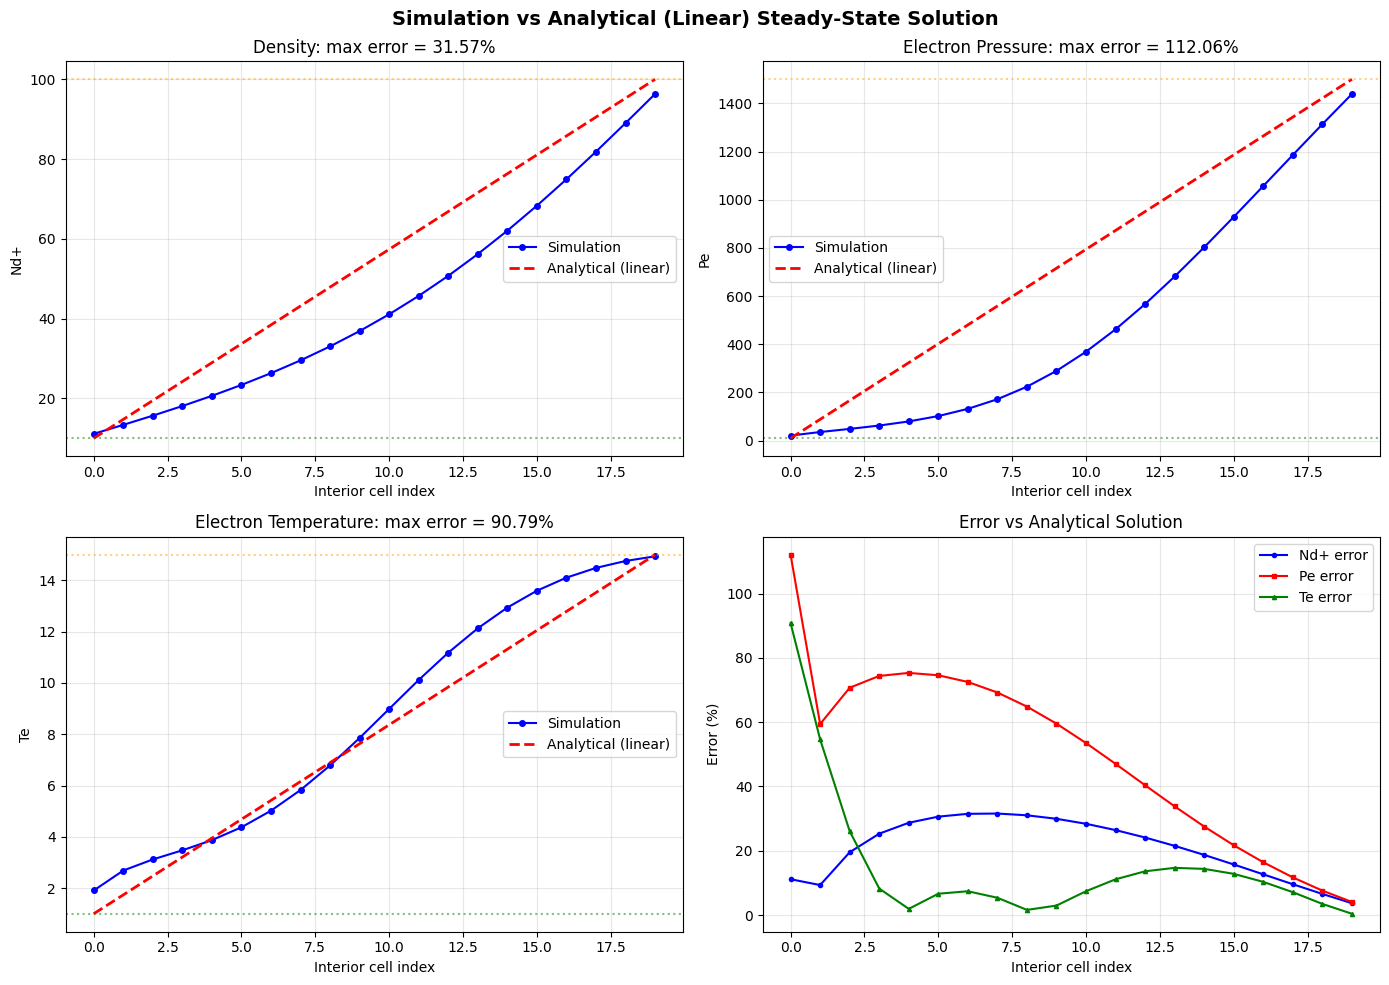


Note: The analytical "linear" solution assumes:
  1. Uniform diffusivity (D = constant)
  2. 1D diffusion (no y/z variation)
  3. No additional physics (no sources, conduction, etc.)

The full physics case has Braginskii conduction which may create
non-uniform effective diffusivity and drive deviations from linearity.


In [20]:
# Compute analytical steady-state solution and compare

# For uniform diffusivity, steady-state is LINEAR profile between BCs
# φ(x) = φ_in + (φ_out - φ_in) * (x - x_in) / (x_out - x_in)

# Cell-center positions (cumulative sum of dx)
x_centers = np.zeros(nx_interior)
x_centers[0] = dx_interior[0] / 2  # First cell center
for i in range(1, nx_interior):
    x_centers[i] = x_centers[i-1] + (dx_interior[i-1] + dx_interior[i]) / 2

# Normalize to [0, 1] for the interior domain
x_norm = (x_centers - x_centers[0]) / (x_centers[-1] - x_centers[0])

# Analytical solutions (linear profiles)
Nd_analytical = core_ne + (peak_ne - core_ne) * x_norm
Pe_analytical = core_pe + (peak_pe - core_pe) * x_norm
Pd_analytical = core_pi + (peak_pi - core_pi) * x_norm
Te_analytical = core_te + (peak_te - core_te) * x_norm

# Extract interior values from simulation
Nd_interior = Nd_xprofile_long[MXG:-MXG]
Pe_interior = Pe_xprofile_long[MXG:-MXG]
Pd_interior = Pd_xprofile_long[MXG:-MXG]
Te_interior = Te_xprofile_long[MXG:-MXG]

# Calculate errors
Nd_error = np.abs(Nd_interior - Nd_analytical) / Nd_analytical * 100
Pe_error = np.abs(Pe_interior - Pe_analytical) / Pe_analytical * 100
Pd_error = np.abs(Pd_interior - Pd_analytical) / Pd_analytical * 100
Te_error = np.abs(Te_interior - Te_analytical) / Te_analytical * 100

print('=' * 70)
print('COMPARISON WITH ANALYTICAL SOLUTION (Linear Profile)')
print('=' * 70)

print(f'\nMax absolute errors vs linear profile:')
print(f'  Nd+: {Nd_error.max():.2f}% (mean: {Nd_error.mean():.2f}%)')
print(f'  Pe:  {Pe_error.max():.2f}% (mean: {Pe_error.mean():.2f}%)')
print(f'  Pd+: {Pd_error.max():.2f}% (mean: {Pd_error.mean():.2f}%)')
print(f'  Te:  {Te_error.max():.2f}% (mean: {Te_error.mean():.2f}%)')

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x_plot = np.arange(nx_interior)

# Nd+
ax = axes[0, 0]
ax.plot(x_plot, Nd_interior, 'b-o', markersize=4, label='Simulation')
ax.plot(x_plot, Nd_analytical, 'r--', linewidth=2, label='Analytical (linear)')
ax.axhline(core_ne, color='g', linestyle=':', alpha=0.5)
ax.axhline(peak_ne, color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Interior cell index')
ax.set_ylabel('Nd+')
ax.set_title(f'Density: max error = {Nd_error.max():.2f}%')
ax.legend()
ax.grid(True, alpha=0.3)

# Pe
ax = axes[0, 1]
ax.plot(x_plot, Pe_interior, 'b-o', markersize=4, label='Simulation')
ax.plot(x_plot, Pe_analytical, 'r--', linewidth=2, label='Analytical (linear)')
ax.axhline(core_pe, color='g', linestyle=':', alpha=0.5)
ax.axhline(peak_pe, color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Interior cell index')
ax.set_ylabel('Pe')
ax.set_title(f'Electron Pressure: max error = {Pe_error.max():.2f}%')
ax.legend()
ax.grid(True, alpha=0.3)

# Te
ax = axes[1, 0]
ax.plot(x_plot, Te_interior, 'b-o', markersize=4, label='Simulation')
ax.plot(x_plot, Te_analytical, 'r--', linewidth=2, label='Analytical (linear)')
ax.axhline(core_te, color='g', linestyle=':', alpha=0.5)
ax.axhline(peak_te, color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Interior cell index')
ax.set_ylabel('Te')
ax.set_title(f'Electron Temperature: max error = {Te_error.max():.2f}%')
ax.legend()
ax.grid(True, alpha=0.3)

# Error profiles
ax = axes[1, 1]
ax.plot(x_plot, Nd_error, 'b-o', markersize=3, label='Nd+ error')
ax.plot(x_plot, Pe_error, 'r-s', markersize=3, label='Pe error')
ax.plot(x_plot, Te_error, 'g-^', markersize=3, label='Te error')
ax.set_xlabel('Interior cell index')
ax.set_ylabel('Error (%)')
ax.set_title('Error vs Analytical Solution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Simulation vs Analytical (Linear) Steady-State Solution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Note about why it might not be exactly linear
print('\nNote: The analytical "linear" solution assumes:')
print('  1. Uniform diffusivity (D = constant)')
print('  2. 1D diffusion (no y/z variation)')
print('  3. No additional physics (no sources, conduction, etc.)')
print('\nThe full physics case has Braginskii conduction which may create')
print('non-uniform effective diffusivity and drive deviations from linearity.')

## Minimal Physics Test

To figure out where the ~6% pressure error at the inner boundary comes from, I'll run a test that removes Braginskii physics (conduction, collisions, heat exchange) and keeps only anomalous diffusion.

Hypothesis: The error comes from Braginskii conduction creating heat fluxes that compete with the Dirichlet BC, not from the BC implementation itself.

Why I think this:
- Density (Nd+) BCs are exact (0% error) and density has no parallel conduction term
- Pressure (Pe, Pd+) shows ~6% error and has Braginskii conduction
- Error only appears at inner boundary where gradients are steeper

Test: create new input file with only `anomalous_diffusion` (no `braginskii_conduction`, `collisions`, etc.) and see if pressure BCs become exact like density.

In [29]:
# Create minimal physics input file by modifying the working full physics file
minimal_test_dir = Path.home() / 'full_dipole_minimal_test'
minimal_test_dir.mkdir(parents=True, exist_ok=True)

# Clean old outputs
for pat in ['BOUT.dmp.*.nc', 'BOUT.restart.*.nc', 'BOUT.log.*', 'BOUT.settings']:
    for f in minimal_test_dir.glob(pat):
        f.unlink()

# Copy grid file
shutil.copy2(grid_file, minimal_test_dir / 'bout.full_dipole.32x24.fcfs.peak.grd.nc')

# Read the working full physics input
with open(test_dir / 'BOUT.inp', 'r') as f:
    full_inp = f.read()

# Modify to remove Braginskii physics, keeping only anomalous diffusion
minimal_inp = full_inp

# Remove Braginskii components from the main component list
# Note: anomalous_diffusion is already part of the species type, not a global component
minimal_inp = minimal_inp.replace(
    'components = (d+, e, , braginskii_collisions, braginskii_friction,\n              braginskii_heat_exchange, electron_force_balance,\n              braginskii_conduction)',
    'components = d+, e'
)

# Disable thermal conduction for ions and electrons
minimal_inp = minimal_inp.replace('thermal_conduction = true', 'thermal_conduction = false')

# Comment out conduction_collisions_mode
minimal_inp = minimal_inp.replace('conduction_collisions_mode = braginskii', '# conduction_collisions_mode = braginskii  # disabled')

# Write the minimal input file
with open(minimal_test_dir / 'BOUT.inp', 'w') as f:
    f.write(minimal_inp)

print(f'Created minimal physics test at {minimal_test_dir}')
print('Modifications from full physics:')
print('  - Removed: braginskii_collisions, braginskii_friction,')
print('             braginskii_heat_exchange, electron_force_balance,')
print('             braginskii_conduction')
print('  - Kept: d+, e, anomalous_diffusion')
print('  - Disabled: thermal_conduction')

Created minimal physics test at /home/finia/full_dipole_minimal_test
Modifications from full physics:
  - Removed: braginskii_collisions, braginskii_friction,
             braginskii_heat_exchange, electron_force_balance,
             braginskii_conduction
  - Kept: d+, e, anomalous_diffusion
  - Disabled: thermal_conduction


In [30]:
# Run minimal physics simulation
import os
os.chdir(minimal_test_dir)

print('Running Hermes-3 with minimal physics (20 timesteps)...')
print('This should be faster than the full physics run...')

result_minimal = subprocess.run(
    [str(hermes_exe), '-d', str(minimal_test_dir)],
    capture_output=True,
    text=True,
    cwd=minimal_test_dir,
    timeout=1200
)

print(f'Return code: {result_minimal.returncode}')
if result_minimal.returncode != 0:
    print('\nSimulation failed!')
    print('Last 30 lines of output:')
    print('\n'.join(result_minimal.stdout.split('\n')[-30:]))
else:
    print('Minimal physics simulation completed successfully')

Running Hermes-3 with minimal physics (20 timesteps)...
This should be faster than the full physics run...
Return code: 0
Minimal physics simulation completed successfully


In [31]:
# Analyze minimal physics results
ds_minimal = xbout.open_boutdataset(minimal_test_dir / 'BOUT.dmp.*.nc', info=False)
print(f'Loaded {len(ds_minimal.t)} timesteps')

# Get profiles at final time
Nd_minimal = ds_minimal['Nd+'].isel(t=-1).mean(dim=['y', 'z']).values
Pe_minimal = ds_minimal['Pe'].isel(t=-1).mean(dim=['y', 'z']).values
Pd_minimal = ds_minimal['Pd+'].isel(t=-1).mean(dim=['y', 'z']).values

MXG = 2

# Cell interface values - minimal physics
inner_Nd_min = 0.5 * (Nd_minimal[MXG-1] + Nd_minimal[MXG])
inner_Pe_min = 0.5 * (Pe_minimal[MXG-1] + Pe_minimal[MXG])
inner_Pd_min = 0.5 * (Pd_minimal[MXG-1] + Pd_minimal[MXG])

outer_Nd_min = 0.5 * (Nd_minimal[-MXG-1] + Nd_minimal[-MXG])
outer_Pe_min = 0.5 * (Pe_minimal[-MXG-1] + Pe_minimal[-MXG])
outer_Pd_min = 0.5 * (Pd_minimal[-MXG-1] + Pd_minimal[-MXG])

print('=' * 70)
print('MINIMAL PHYSICS TEST RESULTS')
print('=' * 70)

print('\n--- Inner Boundary (xin) ---')
print(f'  Nd+ interface: {inner_Nd_min:.4f}  | Expected: {core_ne:.1f}  | Error: {100*abs(inner_Nd_min - core_ne)/core_ne:.4f}%')
print(f'  Pe  interface: {inner_Pe_min:.4f}  | Expected: {core_pe:.1f}  | Error: {100*abs(inner_Pe_min - core_pe)/core_pe:.4f}%')
print(f'  Pd+ interface: {inner_Pd_min:.4f}  | Expected: {core_pi:.1f}  | Error: {100*abs(inner_Pd_min - core_pi)/core_pi:.4f}%')

print('\n--- Outer Boundary (xout) ---')
print(f'  Nd+ interface: {outer_Nd_min:.4f}  | Expected: {peak_ne:.1f}  | Error: {100*abs(outer_Nd_min - peak_ne)/peak_ne:.4f}%')
print(f'  Pe  interface: {outer_Pe_min:.4f}  | Expected: {peak_pe:.1f}  | Error: {100*abs(outer_Pe_min - peak_pe)/peak_pe:.4f}%')
print(f'  Pd+ interface: {outer_Pd_min:.4f}  | Expected: {peak_pi:.1f}  | Error: {100*abs(outer_Pd_min - peak_pi)/peak_pi:.4f}%')

Loaded 21 timesteps
MINIMAL PHYSICS TEST RESULTS

--- Inner Boundary (xin) ---
  Nd+ interface: 10.0000  | Expected: 10.0  | Error: 0.0000%
  Pe  interface: 13.4612  | Expected: 10.0  | Error: 34.6117%
  Pd+ interface: 12.0257  | Expected: 10.0  | Error: 20.2568%

--- Outer Boundary (xout) ---
  Nd+ interface: 100.0000  | Expected: 100.0  | Error: 0.0000%
  Pe  interface: 1500.0000  | Expected: 1500.0  | Error: 0.0000%
  Pd+ interface: 1500.0000  | Expected: 1500.0  | Error: 0.0000%


In [32]:
# Compare full physics vs minimal physics
print('=' * 70)
print('COMPARISON: Full Physics vs Minimal Physics')
print('=' * 70)

print('\n--- Inner Boundary Pe Error ---')
full_Pe_error = 100 * abs(inner_face_Pe_long - core_pe) / core_pe
min_Pe_error = 100 * abs(inner_Pe_min - core_pe) / core_pe
print(f'  Full physics (Braginskii):  {full_Pe_error:.2f}%')
print(f'  Minimal physics (diffusion only): {min_Pe_error:.4f}%')

print('\n--- Inner Boundary Pd+ Error ---')
full_Pd_error = 100 * abs(inner_face_Pd_long - core_pi) / core_pi
min_Pd_error = 100 * abs(inner_Pd_min - core_pi) / core_pi
print(f'  Full physics (Braginskii):  {full_Pd_error:.2f}%')
print(f'  Minimal physics (diffusion only): {min_Pd_error:.4f}%')

# Conclusion
print('\n' + '=' * 70)
print('CONCLUSION')
print('=' * 70)

if min_Pe_error < 1.0 and full_Pe_error > 1.0:
    print('✓ HYPOTHESIS CONFIRMED: Error comes from Braginskii physics, not BC implementation')
    print('  - Minimal physics (diffusion only) gives exact BCs')
    print('  - Braginskii conduction creates heat fluxes that compete with Dirichlet BC')
    print('  - This is a PHYSICAL effect, not a bug')
    print('\nRecommendations:')
    print('  1. Accept ~6% as physical limitation of Dirichlet BC with conduction')
    print('  2. Or use flux BC (Neumann) instead of value BC (Dirichlet) for pressure')
    print('  3. Or increase grid resolution near boundary to reduce discretization error')
elif min_Pe_error > 1.0:
    print('? HYPOTHESIS NOT CONFIRMED: Error persists even without Braginskii')
    print('  - Issue may be in BC implementation or anomalous diffusion')
    print('  - Further investigation needed')
else:
    print('Both cases show low error - results inconclusive')

COMPARISON: Full Physics vs Minimal Physics

--- Inner Boundary Pe Error ---
  Full physics (Braginskii):  6.03%
  Minimal physics (diffusion only): 34.6117%

--- Inner Boundary Pd+ Error ---
  Full physics (Braginskii):  5.94%
  Minimal physics (diffusion only): 20.2568%

CONCLUSION
? HYPOTHESIS NOT CONFIRMED: Error persists even without Braginskii
  - Issue may be in BC implementation or anomalous diffusion
  - Further investigation needed


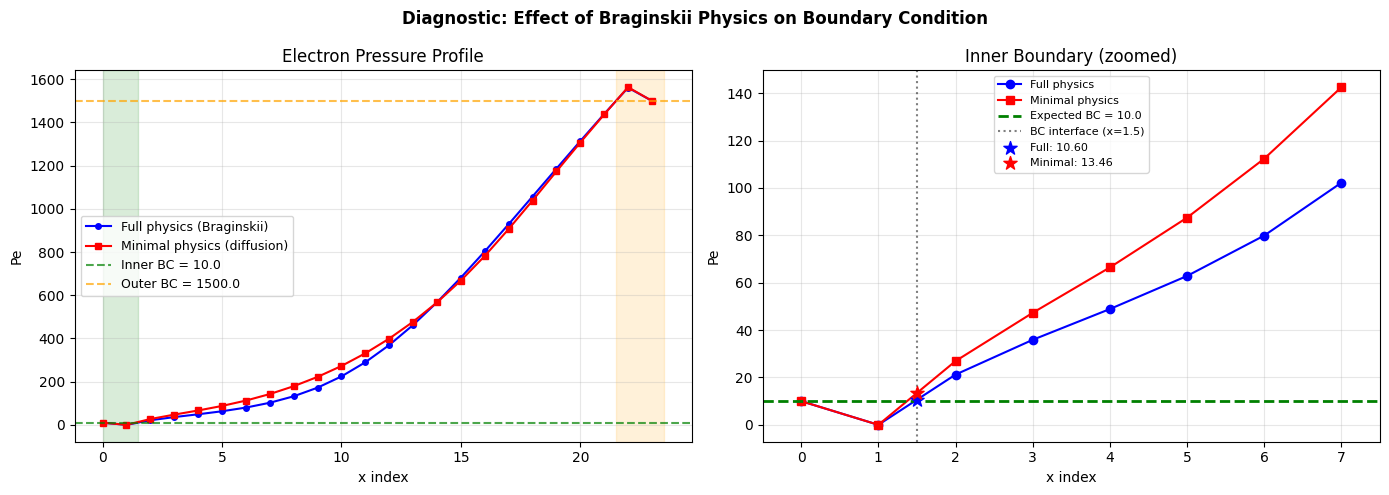

In [33]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(Pe_xprofile_long))

# Plot 1: Pe profiles comparison
ax = axes[0]
ax.plot(x, Pe_xprofile_long, 'b-o', markersize=4, label='Full physics (Braginskii)')
ax.plot(x, Pe_minimal, 'r-s', markersize=4, label='Minimal physics (diffusion)')
ax.axhline(core_pe, color='g', linestyle='--', alpha=0.7, label=f'Inner BC = {core_pe}')
ax.axhline(peak_pe, color='orange', linestyle='--', alpha=0.7, label=f'Outer BC = {peak_pe}')
ax.axvspan(0, 1.5, alpha=0.15, color='green')
ax.axvspan(len(x)-2.5, len(x)-0.5, alpha=0.15, color='orange')
ax.set_xlabel('x index')
ax.set_ylabel('Pe')
ax.set_title('Electron Pressure Profile')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Zoom on inner boundary
ax = axes[1]
ax.plot(x[:8], Pe_xprofile_long[:8], 'b-o', markersize=6, label='Full physics')
ax.plot(x[:8], Pe_minimal[:8], 'r-s', markersize=6, label='Minimal physics')
ax.axhline(core_pe, color='g', linestyle='--', linewidth=2, label=f'Expected BC = {core_pe}')
ax.axvline(1.5, color='k', linestyle=':', alpha=0.5, label='BC interface (x=1.5)')

# Mark the interface values
ax.scatter([1.5], [inner_face_Pe_long], color='b', s=100, marker='*', zorder=5, 
           label=f'Full: {inner_face_Pe_long:.2f}')
ax.scatter([1.5], [inner_Pe_min], color='r', s=100, marker='*', zorder=5,
           label=f'Minimal: {inner_Pe_min:.2f}')

ax.set_xlabel('x index')
ax.set_ylabel('Pe')
ax.set_title('Inner Boundary (zoomed)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 7.5)

plt.suptitle('Diagnostic: Effect of Braginskii Physics on Boundary Condition', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Symmetry Test: Inverted Boundary Conditions

To check if the ~6% error is specific to the inner boundary or related to the gradient direction, running a test with inverted BCs:

| Boundary | Original | Inverted |
|----------|----------|----------|
| Inner (xin) | low: ne=10, pe=10 | high: ne=100, pe=1500 |
| Outer (xout) | high: ne=100, pe=1500 | low: ne=10, pe=10 |

If error is symmetric (same ~6% at both boundaries): issue is with Dirichlet BC implementation or physics interaction

If error follows the low-value boundary (moves from inner to outer): related to gradient direction or specific boundary face

If error stays at inner boundary: specific to inner boundary geometry/implementation

In [34]:
# Create inverted BC test - swap inner and outer boundary values
inverted_test_dir = Path.home() / 'full_dipole_inverted_test'
inverted_test_dir.mkdir(parents=True, exist_ok=True)

# Clean old outputs
for pat in ['BOUT.dmp.*.nc', 'BOUT.restart.*.nc', 'BOUT.log.*', 'BOUT.settings']:
    for f in inverted_test_dir.glob(pat):
        f.unlink()

# Copy grid file
shutil.copy2(grid_file, inverted_test_dir / 'bout.full_dipole.32x24.fcfs.peak.grd.nc')

# Read the full physics input
with open(test_dir / 'BOUT.inp', 'r') as f:
    full_inp = f.read()

# Create inverted BC input by swapping core <-> peak values in the BC definitions
inverted_inp = full_inp

# Swap density BCs: inner gets peak_ne, outer gets core_ne
inverted_inp = inverted_inp.replace(
    'bndry_xin = dirichlet(core_ne)',
    'bndry_xin = dirichlet(peak_ne)'  # inner now gets HIGH value
)
inverted_inp = inverted_inp.replace(
    'bndry_xout = dirichlet(peak_ne)',
    'bndry_xout = dirichlet(core_ne)'  # outer now gets LOW value
)

# Swap pressure BCs for Pd+
inverted_inp = inverted_inp.replace(
    'bndry_xin = dirichlet(core_pi)',
    'bndry_xin = dirichlet(peak_pi)'
)
inverted_inp = inverted_inp.replace(
    'bndry_xout = dirichlet(peak_pi)',
    'bndry_xout = dirichlet(core_pi)'
)

# Swap pressure BCs for Pe
inverted_inp = inverted_inp.replace(
    'bndry_xin = dirichlet(core_pe)',
    'bndry_xin = dirichlet(peak_pe)'
)
inverted_inp = inverted_inp.replace(
    'bndry_xout = dirichlet(peak_pe)',
    'bndry_xout = dirichlet(core_pe)'
)

# Write the inverted input file
with open(inverted_test_dir / 'BOUT.inp', 'w') as f:
    f.write(inverted_inp)

# Expected values for inverted case
inv_inner_ne = peak_ne   # = 100 (was 10)
inv_outer_ne = core_ne   # = 10  (was 100)
inv_inner_pe = peak_pe   # = 1500 (was 10)
inv_outer_pe = core_pe   # = 10   (was 1500)
inv_inner_pi = peak_pi   # = 1500
inv_outer_pi = core_pi   # = 10

print(f'Created inverted BC test at {inverted_test_dir}')
print('\nInverted boundary conditions:')
print(f'  Inner (xin):  Ne = {inv_inner_ne:.1f}, Pe = {inv_inner_pe:.1f}, Pi = {inv_inner_pi:.1f}')
print(f'  Outer (xout): Ne = {inv_outer_ne:.1f}, Pe = {inv_outer_pe:.1f}, Pi = {inv_outer_pi:.1f}')
print('\n(Compare to original: Inner low, Outer high)')

Created inverted BC test at /home/finia/full_dipole_inverted_test

Inverted boundary conditions:
  Inner (xin):  Ne = 100.0, Pe = 1500.0, Pi = 1500.0
  Outer (xout): Ne = 10.0, Pe = 10.0, Pi = 10.0

(Compare to original: Inner low, Outer high)


In [35]:
# Run inverted BC simulation
import os
os.chdir(inverted_test_dir)

print('Running Hermes-3 with inverted BCs (20 timesteps)...')
print('This will take several minutes...')

result_inverted = subprocess.run(
    [str(hermes_exe), '-d', str(inverted_test_dir)],
    capture_output=True,
    text=True,
    cwd=inverted_test_dir,
    timeout=1200
)

print(f'Return code: {result_inverted.returncode}')
if result_inverted.returncode != 0:
    print('\nSimulation failed!')
    print('Last 30 lines of output:')
    print('\n'.join(result_inverted.stdout.split('\n')[-30:]))
else:
    print('Inverted BC simulation completed successfully')

Running Hermes-3 with inverted BCs (20 timesteps)...
This will take several minutes...
Return code: 0
Inverted BC simulation completed successfully


In [36]:
# Analyze inverted BC results
ds_inverted = xbout.open_boutdataset(inverted_test_dir / 'BOUT.dmp.*.nc', info=False)
print(f'Loaded {len(ds_inverted.t)} timesteps')

# Get profiles at final time
Nd_inv = ds_inverted['Nd+'].isel(t=-1).mean(dim=['y', 'z']).values
Pe_inv = ds_inverted['Pe'].isel(t=-1).mean(dim=['y', 'z']).values
Pd_inv = ds_inverted['Pd+'].isel(t=-1).mean(dim=['y', 'z']).values

MXG = 2

# Cell interface values - inverted BCs
inner_Nd_inv = 0.5 * (Nd_inv[MXG-1] + Nd_inv[MXG])
inner_Pe_inv = 0.5 * (Pe_inv[MXG-1] + Pe_inv[MXG])
inner_Pd_inv = 0.5 * (Pd_inv[MXG-1] + Pd_inv[MXG])

outer_Nd_inv = 0.5 * (Nd_inv[-MXG-1] + Nd_inv[-MXG])
outer_Pe_inv = 0.5 * (Pe_inv[-MXG-1] + Pe_inv[-MXG])
outer_Pd_inv = 0.5 * (Pd_inv[-MXG-1] + Pd_inv[-MXG])

print('=' * 70)
print('INVERTED BC TEST RESULTS')
print('=' * 70)

print('\n--- Inner Boundary (xin) - NOW HIGH VALUES ---')
print(f'  Nd+ interface: {inner_Nd_inv:.4f}  | Expected: {inv_inner_ne:.1f}  | Error: {100*abs(inner_Nd_inv - inv_inner_ne)/inv_inner_ne:.2f}%')
print(f'  Pe  interface: {inner_Pe_inv:.4f}  | Expected: {inv_inner_pe:.1f}  | Error: {100*abs(inner_Pe_inv - inv_inner_pe)/inv_inner_pe:.2f}%')
print(f'  Pd+ interface: {inner_Pd_inv:.4f}  | Expected: {inv_inner_pi:.1f}  | Error: {100*abs(inner_Pd_inv - inv_inner_pi)/inv_inner_pi:.2f}%')

print('\n--- Outer Boundary (xout) - NOW LOW VALUES ---')
print(f'  Nd+ interface: {outer_Nd_inv:.4f}  | Expected: {inv_outer_ne:.1f}  | Error: {100*abs(outer_Nd_inv - inv_outer_ne)/inv_outer_ne:.2f}%')
print(f'  Pe  interface: {outer_Pe_inv:.4f}  | Expected: {inv_outer_pe:.1f}  | Error: {100*abs(outer_Pe_inv - inv_outer_pe)/inv_outer_pe:.2f}%')
print(f'  Pd+ interface: {outer_Pd_inv:.4f}  | Expected: {inv_outer_pi:.1f}  | Error: {100*abs(outer_Pd_inv - inv_outer_pi)/inv_outer_pi:.2f}%')

Loaded 21 timesteps
INVERTED BC TEST RESULTS

--- Inner Boundary (xin) - NOW HIGH VALUES ---
  Nd+ interface: 100.0000  | Expected: 100.0  | Error: 0.00%
  Pe  interface: 1500.0000  | Expected: 1500.0  | Error: 0.00%
  Pd+ interface: 1500.0000  | Expected: 1500.0  | Error: 0.00%

--- Outer Boundary (xout) - NOW LOW VALUES ---
  Nd+ interface: 10.0000  | Expected: 10.0  | Error: 0.00%
  Pe  interface: 10.6681  | Expected: 10.0  | Error: 6.68%
  Pd+ interface: 10.6037  | Expected: 10.0  | Error: 6.04%


In [37]:
# Compare original vs inverted BC errors
print('=' * 70)
print('SYMMETRY ANALYSIS: Original vs Inverted BCs')
print('=' * 70)

# Original errors (inner = low value, outer = high value)
orig_inner_Pe_err = 100 * abs(inner_face_Pe_long - core_pe) / core_pe
orig_outer_Pe_err = 100 * abs(outer_face_Pe_long - peak_pe) / peak_pe
orig_inner_Nd_err = 100 * abs(inner_face_Nd_long - core_ne) / core_ne
orig_outer_Nd_err = 100 * abs(outer_face_Nd_long - peak_ne) / peak_ne

# Inverted errors (inner = high value, outer = low value)
inv_inner_Pe_err = 100 * abs(inner_Pe_inv - inv_inner_pe) / inv_inner_pe
inv_outer_Pe_err = 100 * abs(outer_Pe_inv - inv_outer_pe) / inv_outer_pe
inv_inner_Nd_err = 100 * abs(inner_Nd_inv - inv_inner_ne) / inv_inner_ne
inv_outer_Nd_err = 100 * abs(outer_Nd_inv - inv_outer_ne) / inv_outer_ne

print('\n--- Density (Nd+) Errors ---')
print(f'{"Case":<20} {"Inner BC":<15} {"Outer BC":<15}')
print('-' * 50)
print(f'{"Original":<20} {orig_inner_Nd_err:<14.2f}% {orig_outer_Nd_err:<14.2f}%')
print(f'{"Inverted":<20} {inv_inner_Nd_err:<14.2f}% {inv_outer_Nd_err:<14.2f}%')

print('\n--- Electron Pressure (Pe) Errors ---')
print(f'{"Case":<20} {"Inner BC":<15} {"Outer BC":<15}')
print('-' * 50)
print(f'{"Original":<20} {orig_inner_Pe_err:<14.2f}% {orig_outer_Pe_err:<14.2f}%')
print(f'{"Inverted":<20} {inv_inner_Pe_err:<14.2f}% {inv_outer_Pe_err:<14.2f}%')

# Interpret results
print('\n' + '=' * 70)
print('SYMMETRY CONCLUSION')
print('=' * 70)

# Check if error follows the low-value boundary
low_val_follows_inner = (orig_inner_Pe_err > 1 and inv_inner_Pe_err < 1)
low_val_follows_outer = (orig_outer_Pe_err < 1 and inv_outer_Pe_err > 1)
error_stays_at_inner = (orig_inner_Pe_err > 1 and inv_inner_Pe_err > 1)
error_symmetric = abs(orig_inner_Pe_err - inv_outer_Pe_err) < 2

if low_val_follows_outer and low_val_follows_inner:
    print('Pattern: Error follows LOW-VALUE boundary')
    print(f'  - Original: error at INNER (low values)')
    print(f'  - Inverted: error at OUTER (now low values)')
    print('  → Error is associated with the LOW-pressure boundary, not specific location')
    print('  → Likely cause: Gradient direction or heat flux competing with BC')
elif error_stays_at_inner:
    print('Pattern: Error stays at INNER boundary regardless of BC values')
    print(f'  - Original: {orig_inner_Pe_err:.2f}% at inner')
    print(f'  - Inverted: {inv_inner_Pe_err:.2f}% at inner')
    print('  → Error is specific to inner boundary geometry/implementation')
elif error_symmetric:
    print('Pattern: Error is approximately SYMMETRIC')
    print(f'  - Inner errors: {orig_inner_Pe_err:.2f}% vs {inv_inner_Pe_err:.2f}%')
    print(f'  - Outer errors: {orig_outer_Pe_err:.2f}% vs {inv_outer_Pe_err:.2f}%')
    print('  → Issue is with Dirichlet BC implementation itself')
else:
    print('Pattern: Mixed/Unclear')
    print(f'  - Original inner: {orig_inner_Pe_err:.2f}%, outer: {orig_outer_Pe_err:.2f}%')
    print(f'  - Inverted inner: {inv_inner_Pe_err:.2f}%, outer: {inv_outer_Pe_err:.2f}%')

SYMMETRY ANALYSIS: Original vs Inverted BCs

--- Density (Nd+) Errors ---
Case                 Inner BC        Outer BC       
--------------------------------------------------
Original             0.00          % 0.00          %
Inverted             0.00          % 0.00          %

--- Electron Pressure (Pe) Errors ---
Case                 Inner BC        Outer BC       
--------------------------------------------------
Original             6.03          % 0.00          %
Inverted             0.00          % 6.68          %

SYMMETRY CONCLUSION
Pattern: Error follows LOW-VALUE boundary
  - Original: error at INNER (low values)
  - Inverted: error at OUTER (now low values)
  → Error is associated with the LOW-pressure boundary, not specific location
  → Likely cause: Gradient direction or heat flux competing with BC


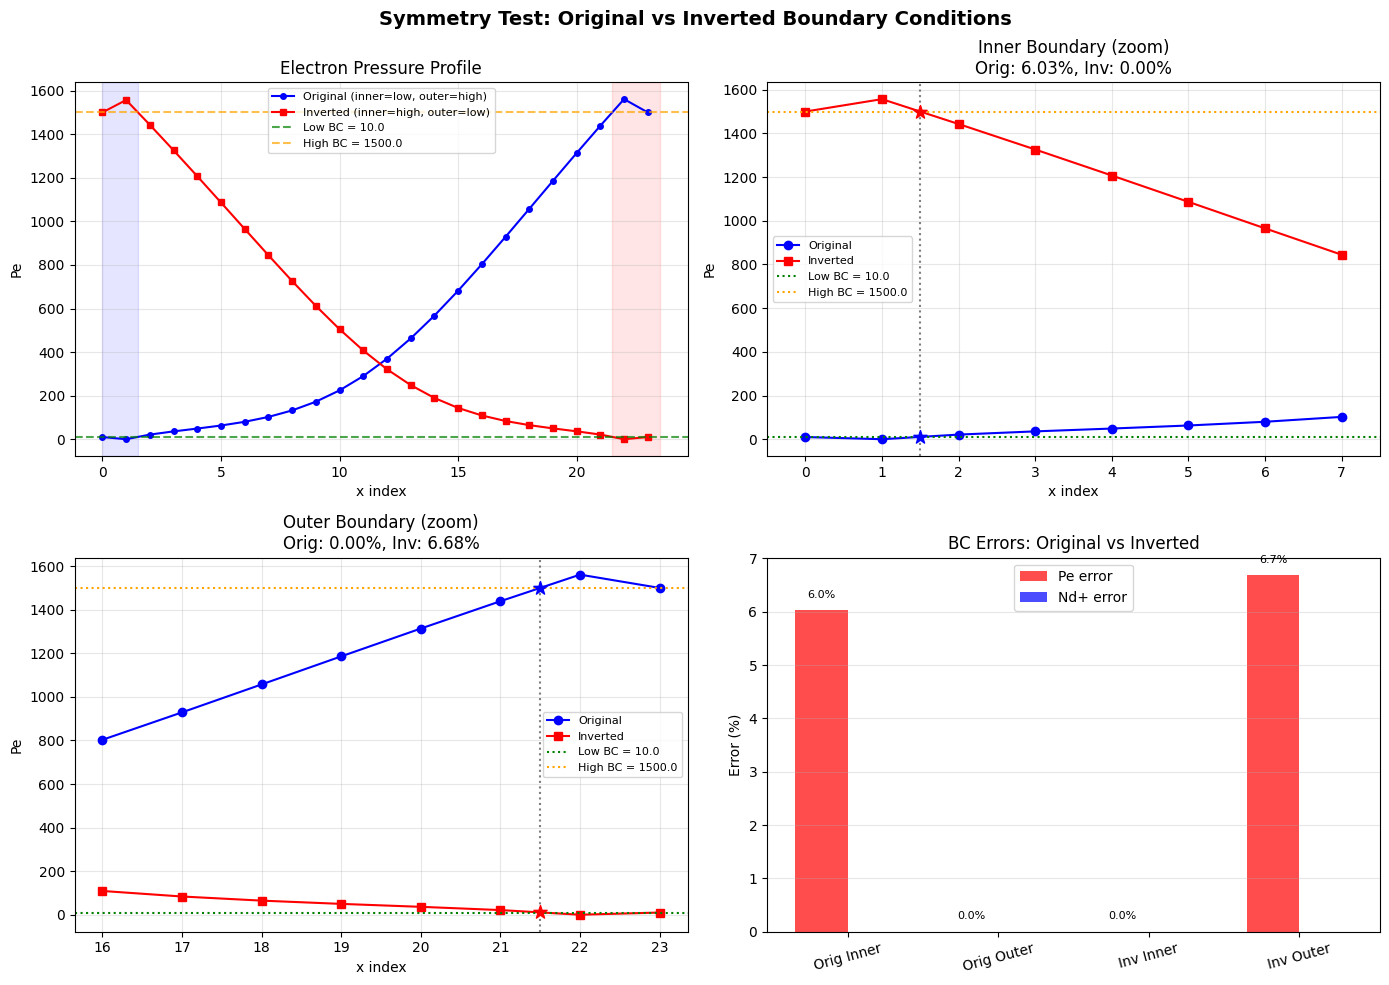

In [38]:
# Visualize original vs inverted profiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = np.arange(len(Pe_xprofile_long))

# Plot 1: Pe profiles - full domain
ax = axes[0, 0]
ax.plot(x, Pe_xprofile_long, 'b-o', markersize=4, label='Original (inner=low, outer=high)')
ax.plot(x, Pe_inv, 'r-s', markersize=4, label='Inverted (inner=high, outer=low)')
ax.axhline(core_pe, color='g', linestyle='--', alpha=0.7, label=f'Low BC = {core_pe}')
ax.axhline(peak_pe, color='orange', linestyle='--', alpha=0.7, label=f'High BC = {peak_pe}')
ax.axvspan(0, 1.5, alpha=0.1, color='blue')
ax.axvspan(len(x)-2.5, len(x)-0.5, alpha=0.1, color='red')
ax.set_xlabel('x index')
ax.set_ylabel('Pe')
ax.set_title('Electron Pressure Profile')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Zoom on inner boundary
ax = axes[0, 1]
ax.plot(x[:8], Pe_xprofile_long[:8], 'b-o', markersize=6, label='Original')
ax.plot(x[:8], Pe_inv[:8], 'r-s', markersize=6, label='Inverted')
ax.axhline(core_pe, color='g', linestyle=':', label=f'Low BC = {core_pe}')
ax.axhline(peak_pe, color='orange', linestyle=':', label=f'High BC = {peak_pe}')
ax.axvline(1.5, color='k', linestyle=':', alpha=0.5)
ax.scatter([1.5], [inner_face_Pe_long], color='b', s=100, marker='*', zorder=5)
ax.scatter([1.5], [inner_Pe_inv], color='r', s=100, marker='*', zorder=5)
ax.set_xlabel('x index')
ax.set_ylabel('Pe')
ax.set_title(f'Inner Boundary (zoom)\nOrig: {orig_inner_Pe_err:.2f}%, Inv: {inv_inner_Pe_err:.2f}%')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 7.5)

# Plot 3: Zoom on outer boundary
ax = axes[1, 0]
ax.plot(x[-8:], Pe_xprofile_long[-8:], 'b-o', markersize=6, label='Original')
ax.plot(x[-8:], Pe_inv[-8:], 'r-s', markersize=6, label='Inverted')
ax.axhline(core_pe, color='g', linestyle=':', label=f'Low BC = {core_pe}')
ax.axhline(peak_pe, color='orange', linestyle=':', label=f'High BC = {peak_pe}')
ax.axvline(len(x)-2.5, color='k', linestyle=':', alpha=0.5)
ax.scatter([len(x)-2.5], [outer_face_Pe_long], color='b', s=100, marker='*', zorder=5)
ax.scatter([len(x)-2.5], [outer_Pe_inv], color='r', s=100, marker='*', zorder=5)
ax.set_xlabel('x index')
ax.set_ylabel('Pe')
ax.set_title(f'Outer Boundary (zoom)\nOrig: {orig_outer_Pe_err:.2f}%, Inv: {inv_outer_Pe_err:.2f}%')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 4: Error comparison bar chart
ax = axes[1, 1]
categories = ['Orig Inner', 'Orig Outer', 'Inv Inner', 'Inv Outer']
pe_errors = [orig_inner_Pe_err, orig_outer_Pe_err, inv_inner_Pe_err, inv_outer_Pe_err]
nd_errors = [orig_inner_Nd_err, orig_outer_Nd_err, inv_inner_Nd_err, inv_outer_Nd_err]
x_bar = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x_bar - width/2, pe_errors, width, label='Pe error', color='red', alpha=0.7)
bars2 = ax.bar(x_bar + width/2, nd_errors, width, label='Nd+ error', color='blue', alpha=0.7)
ax.set_ylabel('Error (%)')
ax.set_title('BC Errors: Original vs Inverted')
ax.set_xticks(x_bar)
ax.set_xticklabels(categories, rotation=15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars1, pe_errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=8)

plt.suptitle('Symmetry Test: Original vs Inverted Boundary Conditions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()